In [3]:
!pip install deap

  Using cached deap-1.4.4-py3-none-any.whl.metadata (13 kB)
  Using cached moocore-0.3.1-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (6.5 kB)
  Using cached cffi-2.0.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 698.0 kB/s eta 0:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 3.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 1.9 MB/s eta 0:00:0000:01
  Attempting uninstall: cffi
    Found existing installation: cffi 1.16.0
    Uninstalling cffi-1.16.0:
      Successfully uninstalled cffi-1.16.0


In [4]:
# ============================================
# Distributed Evolutionary Algorithm using DEAP
# Single-Cell Jupyter Notebook Implementation
# ============================================

import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

#
# Step 1: Define Optimization Problem
# Minimize Sphere Function
#
def evaluate(individual):
    return sum(x**2 for x in individual),

#
# Step 2: Create Fitness & Individual
#
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

#
# Step 3: Toolbox Setup
#
toolbox = base.Toolbox()

toolbox.register("attr_float", random.uniform, -10, 10)

toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual,
    toolbox.attr_float,
    n=5
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)

#
# Step 4: Initialize Population
#
population = toolbox.population(n=50)
generations = 40
cx_prob = 0.7
mut_prob = 0.2

best_fitness = []

#
# Step 5: Evolutionary Loop
#
for gen in range(generations):

    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))

    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < cx_prob:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        if random.random() < mut_prob:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]

    for ind in invalid_ind:
        ind.fitness.values = toolbox.evaluate(ind)

    population[:] = offspring

    fits = [ind.fitness.values[0] for ind in population]
    best_fitness.append(min(fits))

#
# Step 6: Results
#
best_individual = tools.selBest(population, 1)[0]

print("Best Individual:", best_individual)
print("Best Fitness Value:", best_individual.fitness.values[0])

Best Individual: [-0.029355774344694868, -0.0019379960787165081, 0.004542970187152046, -6.664491658944435e-07, -0.006687152168043482]
Best Fitness Value: 0.0009308738988618414


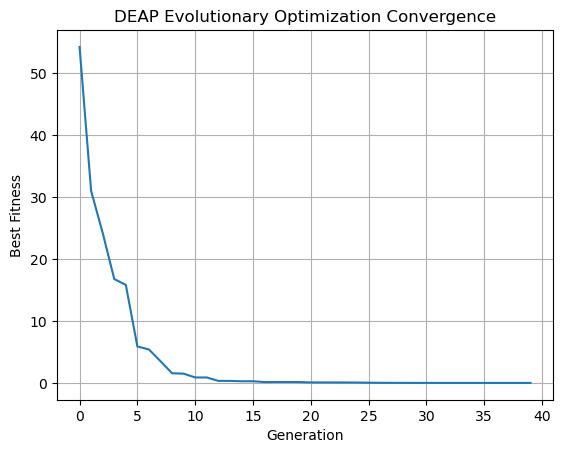

In [5]:
#
# Step 7: Convergence Plot
#
plt.figure()

plt.plot(best_fitness)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("DEAP Evolutionary Optimization Convergence")

plt.grid()
plt.show()